In [18]:
import pandas as pd

df = pd.read_csv("online_education_dataset.csv")

df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [19]:
print(df.columns.tolist())

['id_student', 'gender', 'region', 'highest_education', 'studied_credits', 'imd_band', 'total_clicks', 'avg_score', 'engagement_level', 'performance_level', 'risk_level', 'pass_flag', 'dropout_flag', 'final_result']


In [20]:
import pandas as pd

df = pd.read_csv("online_education_dataset.csv")

df.shape

(32593, 14)

In [21]:
features = [
    'studied_credits',
    'total_clicks',
    'avg_score'
]

target = 'pass_flag'

data = df[features + [target]]

data.head()

,studied_credits,total_clicks,avg_score,pass_flag
0,240,934.0,82.0,1
1,60,1435.0,66.4,1
2,60,281.0,NaN,0
3,60,2158.0,76.0,1
4,60,1034.0,54.4,1


In [22]:
data.isnull().sum()

studied_credits       0
total_clicks       2852
avg_score          5866
pass_flag             0
dtype: int64

In [23]:
data['total_clicks'] = data['total_clicks'].fillna(
    data['total_clicks'].mean()
)

data['avg_score'] = data['avg_score'].fillna(
    data['avg_score'].mean()
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4624\3616023918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['total_clicks'] = data['total_clicks'].fillna(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4624\3616023918.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['avg_score'] = data['avg_score'].fillna(


In [24]:
data.isnull().sum()

studied_credits    0
total_clicks       0
avg_score          0
pass_flag          0
dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(22815, 3)
(9778, 3)


In [26]:
print(X_train.shape)
print(X_test.shape)

(22815, 3)
(9778, 3)


In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7654939660462262


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.77      0.78      5162
           1       0.75      0.76      0.75      4616

    accuracy                           0.77      9778
   macro avg       0.76      0.77      0.77      9778
weighted avg       0.77      0.77      0.77      9778



In [31]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3965 1197]
 [1096 3520]]


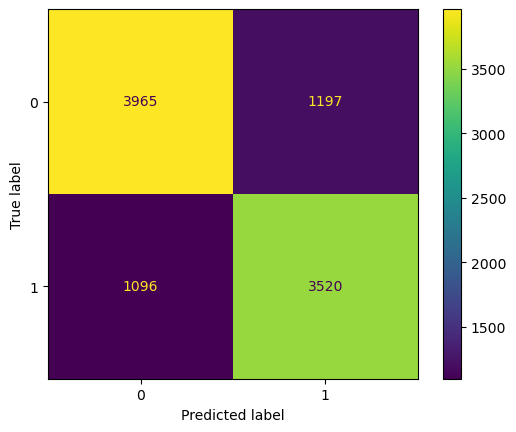

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [33]:
import joblib

joblib.dump(model, "student_model.pkl")

['student_model.pkl']

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_pred
)

print("Pipeline Accuracy:", pipeline_accuracy)

Pipeline Accuracy: 0.7654939660462262


In [36]:
import joblib

joblib.dump(pipeline, "student_model.pkl")

['student_model.pkl']